<a href="https://colab.research.google.com/github/AIPI510/aipi510-fall24/blob/lecture-code/week_5_lecture_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis Example

In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the covid19 dataset from week4
blood_pressure_data = pd.read_csv('../data/week4/blood_pressure.csv')
heart_rate_data = pd.read_csv('../data/week4/heart_rate.csv')
hrv_measurements_data = pd.read_csv('../data/week4/hrv_measurements.csv')
participants_data = pd.read_csv('../data/week4/participants.csv')
scales_description_data = pd.read_csv('../data/week4/scales_description.csv')
sleep_data= pd.read_csv('../data/week4/sleep.csv')
wearable_data = pd.read_csv('../data/week4/wearables.csv')
weather_data = pd.read_csv('../data/week4/weather.csv')


## Questions we are asking:
* What are the dimensions of the dataset (number of rows and columns)?
* What are the data types of the variables (numerical, categorical, text, etc.)?
* Are there any missing values, and if so, how are they represented?


In [ ]:
# Focus on sleep_data and wearable_data
main_datasets = {
    'Sleep Data': sleep_data,
    'Wearable Data': wearable_data
}

for name, df in main_datasets.items():
    print(f"\n{name}:")
    print(f"  Dimensions: {df.shape}")
    print(f"  Data Types:\n{df.dtypes}")

# Check for common columns
print("\nColumn Comparison for Data Integration:")
sleep_cols = set(sleep_data.columns)
wearable_cols = set(wearable_data.columns)
common_cols = sleep_cols.intersection(wearable_cols)
print(f"Common columns: {list(common_cols)}")
print(f"Sleep unique columns: {list(sleep_cols - wearable_cols)}")
print(f"Wearable unique columns: {list(wearable_cols - sleep_cols)}")

Health Data Structure Analysis

Sleep Data:
Dimensions: (425, 12)
Data Types:
user_code                object
day                      object
sleep_begin              object
sleep_end                object
sleep_duration          float64
sleep_awake_duration    float64
sleep_rem_duration      float64
sleep_light_duration    float64
sleep_deep_duration     float64
pulse_min               float64
pulse_max               float64
pulse_average           float64
dtype: object

Wearable Data:
Dimensions: (3098, 18)
Data Types:
user_code                           object
day                                 object
resting_pulse                      float64
pulse_average                      float64
pulse_min                          float64
pulse_max                          float64
average_spo2_value                 float64
body_temperature_avg               float64
stand_hours_total                  float64
steps_count                        float64
distance                           float64


## Interpretation

This indicates that sleep data have 425 rows where as wearable data is a much larger dataset with 3098 rows.
There are some common columns like pulse_average, pulse_min and pulse_max.
We can potentially merge two tables using user_code as the key and analyze them toghether. 


## Questions we are asking:
* What are the central tendency measures (mean, median, mode) for numerical variables?
* What are the measures of dispersion (range, variance, standard deviation) for numerical variables?
* What is the distribution of the variables (normal, skewed, etc.)?


In [17]:
# Descriptive Statistics
print("\nDescriptive Statistics")
print("----------------------")

# Analyze numerical columns in sleep data
sleep_numeric = sleep_data.select_dtypes(include=[np.number])
wearable_numeric = wearable_data.select_dtypes(include=[np.number])

print("\n--- SLEEP DATA STATISTICS ---")
print("Central Tendency Measures:")
print(sleep_numeric.describe().loc[['mean', '50%']])
print("\nDispersion Measures:")
print(sleep_numeric.describe().loc[['std', 'min', 'max']])

print("\nDistribution Measures (Sleep Data):")
print("Skewness:")
print(sleep_numeric.skew())
print("Kurtosis:")
print(sleep_numeric.kurt())

print("\n--- WEARABLE DATA STATISTICS ---")
print("Central Tendency Measures:")
print(wearable_numeric.describe().loc[['mean', '50%']])
print("\nDispersion Measures:")
print(wearable_numeric.describe().loc[['std', 'min', 'max']])

print("\nDistribution Measures (Wearable Data):")
print("Skewness:")
print(wearable_numeric.skew())
print("Kurtosis:")
print(wearable_numeric.kurt())


Descriptive Statistics
----------------------

--- SLEEP DATA STATISTICS ---
Central Tendency Measures:
      sleep_duration  sleep_awake_duration  sleep_rem_duration  \
mean    25699.731765           2733.333333         6518.571429   
50%     26041.000000           2490.000000         6240.000000   

      sleep_light_duration  sleep_deep_duration  pulse_min  pulse_max  \
mean          14514.740741          4280.285714  60.533333  89.866667   
50%           17340.000000          4230.000000  58.000000  93.000000   

      pulse_average  
mean      68.880733  
50%       65.857000  

Dispersion Measures:
     sleep_duration  sleep_awake_duration  sleep_rem_duration  \
std      7773.80547             671.90029         2081.613385   
min       930.00000            1740.00000         2820.000000   
max     47460.00000            4200.00000         8730.000000   

     sleep_light_duration  sleep_deep_duration   pulse_min   pulse_max  \
std            8078.12629          2089.766547   12.8

## Interpretation
#### Sleep Data Analysis
In the sleep dataset, the average sleep duration was about 7.1 hours, with a median of 7.23 hours, suggesting the central tendency is fairly balanced. The standard deviation of 2.16 hours indicates moderate variability, with values ranging from 0.3 to 13 hours, which highlights some extreme cases. The skewness of -0.56 suggests a slight to moderate left skew, meaning some individuals reported unusually short sleep durations. The kurtosis of 0.8 indicates a flatter distribution than normal, with fewer extreme outliers.

#### Wearable Data Analysis  
In the wearable dataset, the average daily active calories burned was about 751 calories, while the median was much lower at 180 calories, indicating that the data is heavily right-skewed. The wide standard deviation of 916 calories, along with a range from 1 to 5,423 calories, highlights very high variability. Skewness of 1.10 confirms a positive skew, and a kurtosis of 0.43 suggests slightly heavier tails than a normal distribution, meaning a few extreme values strongly influence the average.

For average pulse, the mean was 78 bpm and the median was 76 bpm, which are fairly close and suggest a reasonably symmetric distribution overall. The standard deviation of 14 bpm shows moderate variation, though the range from 48 to 163 bpm reveals some unusually high values. Skewness of 0.98 points to a right-skew, and the kurtosis of 1.96 indicates heavier tails than normal, confirming the presence of outliers with elevated heart rates.

## Questions we are asking:
* Are there any duplicated rows or inconsistent values?
* Are there any outliers or extreme values that need attention?
* Do the values make sense based on the context and domain knowledge?

In [ ]:
# Data Quality
print("\nData Quality")
print("--- SLEEP DATA QUALITY ---")
print(f"Duplicated Rows: {sleep_data.duplicated().sum()}")

print("\nMost Frequent Values (Sleep):")
for col in sleep_data.select_dtypes(include=['object']).columns:
    print(f"  {col}: {sleep_data[col].value_counts().head(3).to_dict()}")

print("\n--- WEARABLE DATA QUALITY ---")
print(f"Duplicated Rows: {wearable_data.duplicated().sum()}")

# Check for impossible values in wearable data
print("\nData Validation Checks:")
for col in wearable_numeric.columns:
    negative_values = (wearable_numeric[col] < 0).sum()
    if negative_values > 0:
        print(f"  {col}: {negative_values} negative values found")

print("\nMost Frequent Values (Wearable):")
for col in wearable_data.select_dtypes(include=['object']).columns:
    print(f"  {col}: {wearable_data[col].value_counts().head(3).to_dict()}")

# Outlier detection using IQR method
print("\n--- OUTLIER DETECTION ---")
def detect_outliers_iqr(df, columns):
    outliers_info = {}
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
        outliers_info[col] = outliers

    return outliers_info

sleep_outliers = detect_outliers_iqr(sleep_data, sleep_numeric.columns)
wearable_outliers = detect_outliers_iqr(wearable_data, wearable_numeric.columns)

print("Sleep Data Outliers (IQR method):")
for col, count in sleep_outliers.items():
    print(f"  {col}: {count} outliers")

print("\nWearable Data Outliers (IQR method):")
for col, count in wearable_outliers.items():
    print(f"  {col}: {count} outliers")


Data Quality
--- SLEEP DATA QUALITY ---
Duplicated Rows: 0

Most Frequent Values (Sleep):
  user_code: {'6be5033971': 108, '35c7355282': 103, '0d297d2410': 69}
  day: {'2020-05-16': 6, '2020-05-15': 6, '2020-05-19': 6}
  sleep_begin: {'2020-05-19 00:03:00': 2, '2020-03-17 01:35:00': 1, '2020-03-13 23:00:00': 1}
  sleep_end: {'2019-12-31 08:45:22': 1, '2020-03-18 09:30:00': 1, '2020-03-15 07:25:00': 1}

--- WEARABLE DATA QUALITY ---
Duplicated Rows: 0

Data Validation Checks:

Most Frequent Values (Wearable):
  user_code: {'0d297d2410': 170, '6be5033971': 162, 'fcf3ea75b0': 153}
  day: {'2020-05-03': 41, '2020-04-28': 38, '2020-04-20': 37}

--- OUTLIER DETECTION ---
Sleep Data Outliers (IQR method):
  sleep_duration: 17 outliers
  sleep_awake_duration: 2 outliers
  sleep_rem_duration: 0 outliers
  sleep_light_duration: 0 outliers
  sleep_deep_duration: 0 outliers
  pulse_min: 1 outliers
  pulse_max: 1 outliers
  pulse_average: 1 outliers

Wearable Data Outliers (IQR method):
  resting_

## Interpretation

There are no duplicate rows in either dataset. In the sleep data, user_code "6be5033971" has 108 records, about one-fourth of the dataset, with a few other users also contributing many rows. This means one person’s data can heavily influence the mean and standard deviation.

The wearable data covers more users overall. The top users have around 150–170 records each, so their influence is less dominant compared to the sleep data.

Outlier checks show only a few in the sleep dataset, while the wearable dataset has many more, especially in calories burned, distance, pulse averages, and flights climbed. This shows higher variability in activity data compared to sleep data.

## Questions we are asking:

* Is there any correlation between pairs of numerical variables?
* Are there any noticeable patterns or trends in the data?
* How are categorical variables related to numerical variables?


Variable Relationships
----------------------

--- SLEEP DATA CORRELATIONS ---
Sleep Data Correlation Matrix:
                      sleep_duration  sleep_awake_duration  \
sleep_duration                 1.000                -0.176   
sleep_awake_duration          -0.176                 1.000   
sleep_rem_duration             0.963                -0.383   
sleep_light_duration           0.409                 0.466   
sleep_deep_duration            0.552                 0.284   
pulse_min                      0.287                -0.938   
pulse_max                      0.542                -1.000   
pulse_average                  0.244                -0.935   

                      sleep_rem_duration  sleep_light_duration  \
sleep_duration                     0.963                 0.409   
sleep_awake_duration              -0.383                 0.466   
sleep_rem_duration                 1.000                 0.754   
sleep_light_duration               0.754                 1.000   


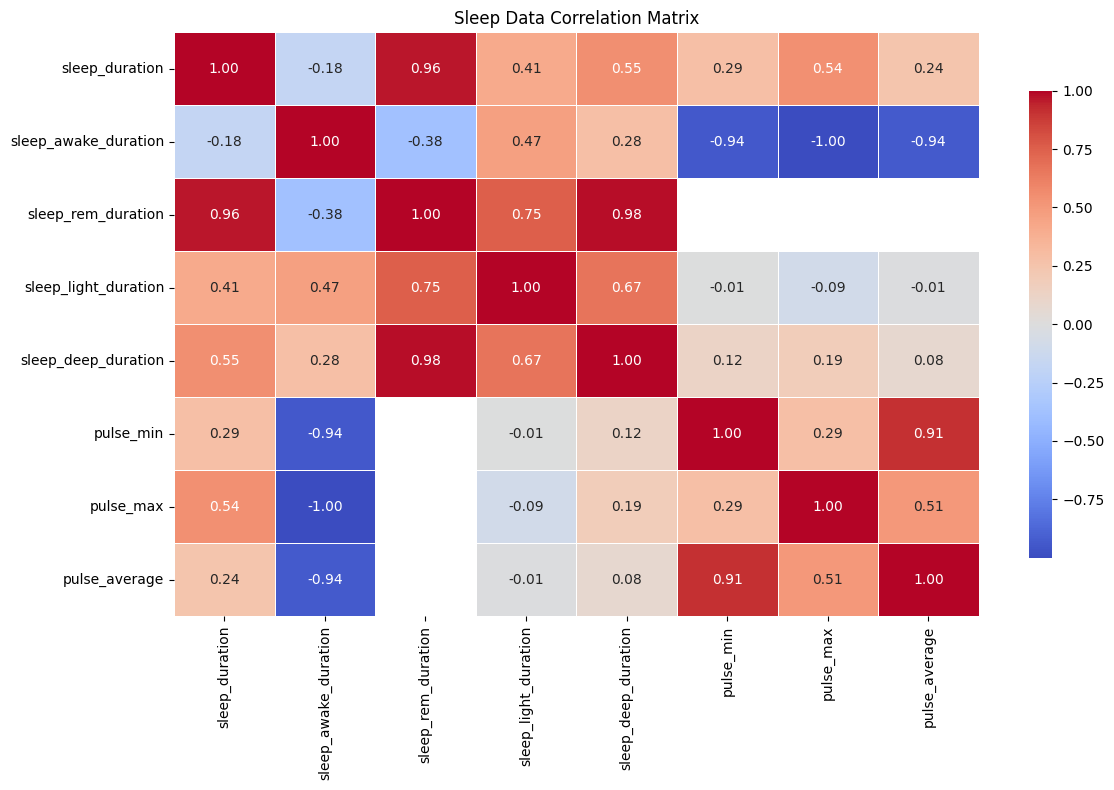

Strong correlations in Sleep Data (|r| >= 0.7):
  sleep_awake_duration ↔ pulse_max: -1.000
  sleep_rem_duration ↔ sleep_deep_duration: 0.977
  sleep_duration ↔ sleep_rem_duration: 0.963
  sleep_awake_duration ↔ pulse_min: -0.938
  sleep_awake_duration ↔ pulse_average: -0.935
  pulse_min ↔ pulse_average: 0.906
  sleep_rem_duration ↔ sleep_light_duration: 0.754
pulse_max rows: 15
sleep_awake_duration rows: 9


In [ ]:
# Variable Relationships
print("\nVariable Relationships")
print("----------------------")

print("\n--- SLEEP DATA CORRELATIONS ---")
sleep_corr = sleep_numeric.corr()
print("Sleep Data Correlation Matrix:")
print(sleep_corr.round(3))

# Visualize sleep data correlations
plt.figure(figsize=(12, 8))
sns.heatmap(sleep_corr, annot=True, cmap='coolwarm', fmt='.2f', 
            linewidths=.5, cbar_kws={"shrink": .8})
plt.title('Sleep Data Correlation Matrix')
plt.tight_layout()
plt.show()


def find_strong_correlations(corr_matrix, threshold=0.7):
    strong_corr = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            corr_val = corr_matrix.iloc[i, j]
            if abs(corr_val) >= threshold:
                strong_corr.append((corr_matrix.columns[i],
                                    corr_matrix.columns[j],
                                    corr_val))
    # Sort by absolute correlation strength
    return sorted(strong_corr, key=lambda x: abs(x[2]), reverse=True)

sleep_strong = find_strong_correlations(sleep_corr)

print("Strong correlations in Sleep Data (|r| >= 0.7):")
for var1, var2, corr in sleep_strong:
    print(f"  {var1} ↔ {var2}: {corr:.3f}")


## Interpretation - Health Data Correlations

#### Sleep Data Relationships
In the sleep data, the strongest positive correlations are between REM and deep sleep duration (0.977) and between total sleep duration and REM duration (0.963). This makes sense since longer total sleep often means longer REM and deep sleep.

There are also very strong negative correlations between awake duration and pulse values (e.g., -1.000 with pulse_max, -0.938 with pulse_min). I need to better understand what "sleep_awake_duration" means to interpretate this correlation.

## Questions we are asking:

* How can the variables be visualized effectively (histograms, scatterplots, box plots, etc.)?
* Do the visualizations reveal any interesting patterns or insights?
* Are there any subgroups or clusters that can be identified visually?


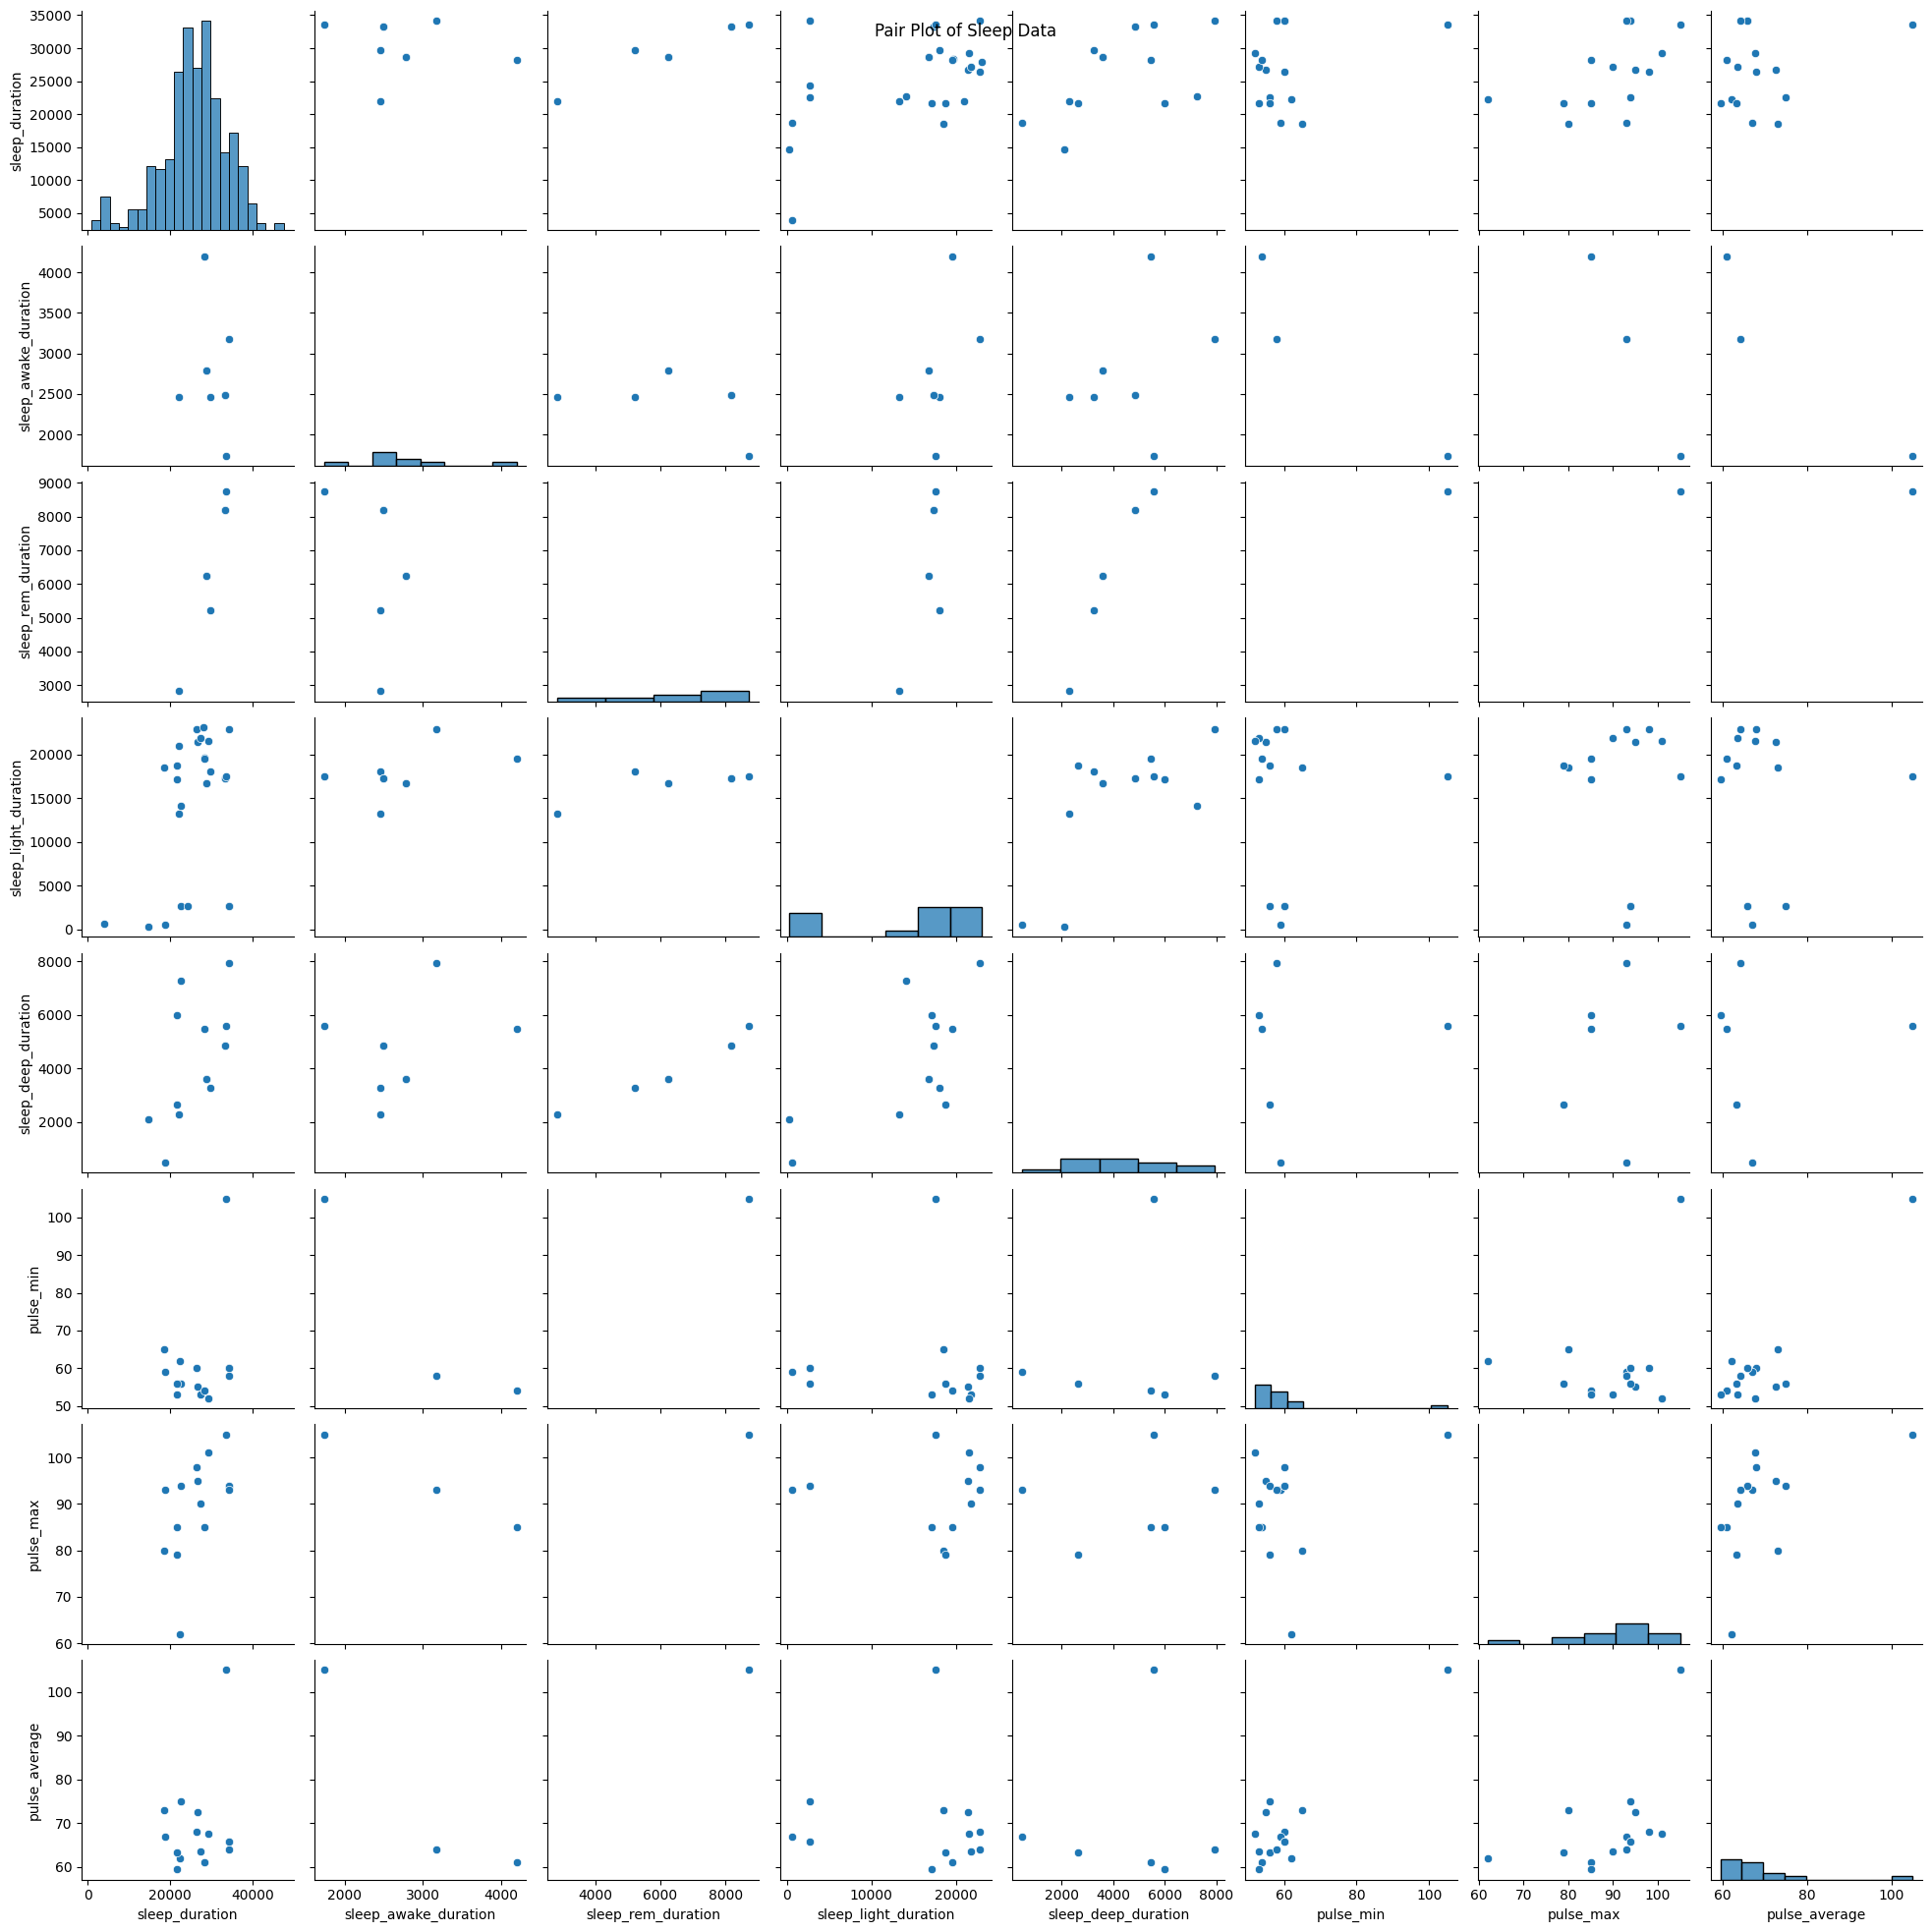

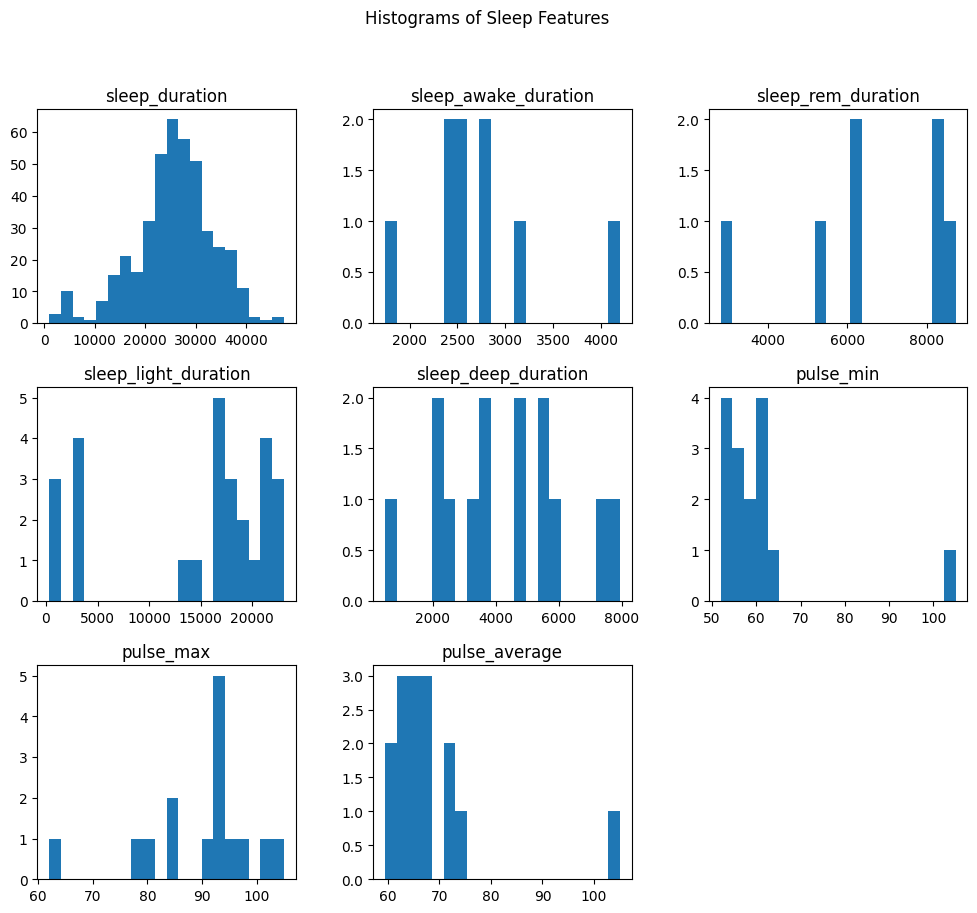

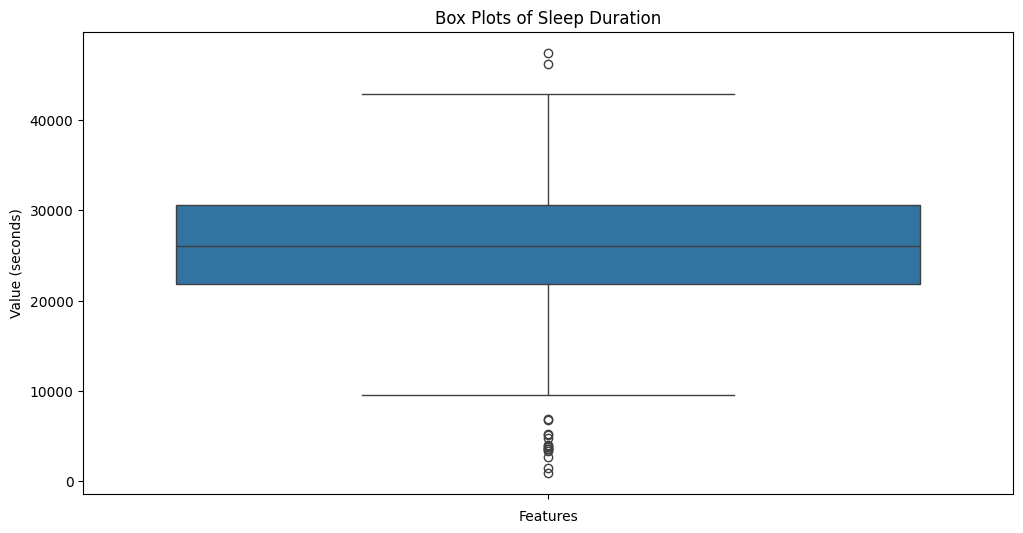

In [33]:
# Data Visualization
sns.pairplot(sleep_numeric)
plt.suptitle("Pair Plot of Sleep Data")
plt.show()

sleep_numeric.hist(bins=20, figsize=(12, 10), grid=False)
plt.suptitle("Histograms of Sleep Features")
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(data=sleep_numeric.sleep_duration)
plt.title("Box Plots of Sleep Duration")
plt.xlabel("Features")
plt.ylabel("Value (seconds)")
plt.show()

## Interpretation - Health Data Visualizations

The pair plot shows relationships between sleep durations and pulse values.

The histograms reveal that sleep duration distribution slightly right skewed, but pretty normally. Many other data don't have enough data size to show a clear and meaningful distribution.

The box plots highlight clear outliers, especially in sleep duration, suggesting unusually short sleep sessions.

## Questions we are asking:

* Are there any new features that can be derived from the existing ones?
* Is there a need to transform or scale any variables?
* Are there any variables that can be combined or decomposed?


Sleep Duration Bounds: 8742.50 – 43714.50


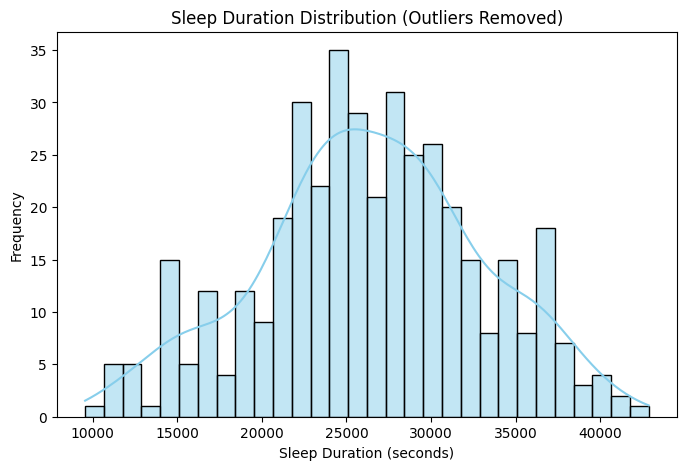

In [ ]:
# Feature Engineering
Q1 = sleep_numeric["sleep_duration"].quantile(0.25)
Q3 = sleep_numeric["sleep_duration"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Sleep Duration Bounds: {lower_bound:.2f} – {upper_bound:.2f}")

# Filter dataset to exclude outliers
sleep_no_outliers = sleep_numeric[(sleep_numeric["sleep_duration"] >= lower_bound) &
                          (sleep_numeric["sleep_duration"] <= upper_bound)]
plt.figure(figsize=(8, 5))
sns.histplot(sleep_no_outliers["sleep_duration"], bins=30, kde=True, color="skyblue")
plt.title("Sleep Duration Distribution (Outliers Removed)")
plt.xlabel("Sleep Duration (seconds)")
plt.ylabel("Frequency")
plt.show()



## Interpretation

Because outliers were excluded, the extreme short and long sleep sessions are gone, so the distribution now reflects the typical sleep pattern more clearly.

If the curve is roughly bell-shaped, it suggests sleep duration is centered around an average (likely in the 20k–30k seconds range, ~5.5–8 hours).